#Spam SMS 분류
:SMS 메세지가 스팸인지 아닌지를 예측

In [125]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM, Dense,Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import zipfile
import requests
from io import BytesIO#집파일 풀기

import warnings
warnings.filterwarnings('ignore')

In [126]:
#데이터 로드:SMS Spam Collection Dataset
from urllib import response

url="https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
#데이터 유명함
response=requests.get(url)
response#200:Ok
with zipfile.ZipFile(BytesIO(response.content)) as zip_ref:
    with zip_ref.open("SMSSpamCollection") as file:
        data=pd.read_csv(file,sep='\t',names=['label','message'])#컬럼이름

In [127]:
data.head()#무선통신 햄

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [128]:
data.label.unique()#ham이 먼저 있어 0번

<StringArray>
['ham', 'spam']
Length: 2, dtype: str

In [129]:
#데이터 전처리
#라벨인코더(딥러닝):'ham'->0,'spam'->1#왜? /for dictionary

label_encoder=LabelEncoder()
data['label']=label_encoder.fit_transform(data['label'])
data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [130]:
#텍스트 토큰화
tokenizer= Tokenizer(num_words=5000)
tokenizer.fit_on_texts(data['message'])
X=tokenizer.texts_to_sequences(data['message'])
X

[[49,
  471,
  4436,
  842,
  755,
  658,
  64,
  8,
  1327,
  88,
  123,
  351,
  1328,
  148,
  2997,
  1329,
  67,
  58,
  4437,
  144],
 [46, 336, 1499, 472, 6, 1940],
 [47,
  489,
  8,
  19,
  4,
  797,
  901,
  2,
  176,
  1941,
  1105,
  659,
  1942,
  2331,
  261,
  2332,
  71,
  1941,
  2,
  1943,
  2,
  337,
  489,
  555,
  960,
  73,
  391,
  174,
  660,
  392,
  2998],
 [6, 248, 150, 23, 382, 2999, 6, 139, 154, 57, 150],
 [1024, 1, 98, 108, 69, 490, 2, 961, 69, 1944, 221, 112, 473],
 [798,
  129,
  67,
  1690,
  145,
  109,
  158,
  1945,
  21,
  7,
  38,
  338,
  89,
  902,
  55,
  116,
  414,
  3,
  44,
  12,
  14,
  86,
  1946,
  46,
  365,
  960,
  4438,
  2,
  68,
  323,
  232,
  2,
  3000],
 [210, 11, 633, 9, 25, 55, 2, 383, 36, 10, 110, 718, 10, 55, 4439, 4440],
 [72,
  235,
  13,
  1204,
  2333,
  2334,
  1947,
  2335,
  2336,
  2337,
  799,
  118,
  109,
  609,
  72,
  13,
  1025,
  12,
  51,
  1691,
  843,
  393,
  2,
  1106,
  13,
  249,
  1025],
 [719,
  72,
  4

In [131]:
len(X)

5572

In [132]:
print(X)#2차원

[[49, 471, 4436, 842, 755, 658, 64, 8, 1327, 88, 123, 351, 1328, 148, 2997, 1329, 67, 58, 4437, 144], [46, 336, 1499, 472, 6, 1940], [47, 489, 8, 19, 4, 797, 901, 2, 176, 1941, 1105, 659, 1942, 2331, 261, 2332, 71, 1941, 2, 1943, 2, 337, 489, 555, 960, 73, 391, 174, 660, 392, 2998], [6, 248, 150, 23, 382, 2999, 6, 139, 154, 57, 150], [1024, 1, 98, 108, 69, 490, 2, 961, 69, 1944, 221, 112, 473], [798, 129, 67, 1690, 145, 109, 158, 1945, 21, 7, 38, 338, 89, 902, 55, 116, 414, 3, 44, 12, 14, 86, 1946, 46, 365, 960, 4438, 2, 68, 323, 232, 2, 3000], [210, 11, 633, 9, 25, 55, 2, 383, 36, 10, 110, 718, 10, 55, 4439, 4440], [72, 235, 13, 1204, 2333, 2334, 1947, 2335, 2336, 2337, 799, 118, 109, 609, 72, 13, 1025, 12, 51, 1691, 843, 393, 2, 1106, 13, 249, 1025], [719, 72, 4, 844, 441, 236, 3, 17, 109, 442, 2, 3001, 1330, 151, 962, 2, 127, 16, 3002, 127, 415, 3003, 516, 963, 581, 64], [136, 13, 97, 686, 1026, 26, 133, 6, 82, 1205, 2, 491, 2, 5, 324, 535, 903, 36, 339, 12, 47, 16, 5, 97, 491, 243,

In [133]:
#padding
X=pad_sequences(X,maxlen=100)#최대 183

In [134]:
y=data['label'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5572,))

In [135]:
#훈련 및 테스트 분리
from sklearn.model_selection import train_test_split
train_input, val_input, train_target, val_target = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#LSTM 모델 생성 및 훈련
#모델 평가

In [136]:
train_seq = train_input
val_seq = val_input

print(train_seq.shape, val_seq.shape)

(4457, 100) (1115, 100)


In [137]:
#LSTM 모델 생성 및 훈련
from tensorflow import keras
model=keras.Sequential()
model.add(keras.layers.Embedding(5000,16))
model.add(keras.layers.LSTM(8))
model.add(keras.layers.Dense(1,activation='sigmoid'))

model.build(input_shape=(None,100))
model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 16)        │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,809 (315.66 KB)

 Trainable params: 80,809 (315.66 KB)

 Non-trainable params: 0 (0.00 B)

In [138]:
#compile
rmsprop=keras.optimizers.RMSprop(learning_rate=1e-4)#0.0001
model.compile(
    optimizer=rmsprop,#adam도 가능
    loss='binary_crossentropy',
    metrics=['accuracy']
)

checkpoint_cb=keras.callbacks.ModelCheckpoint("../Data/best-lstm-model.keras")#저장 내가 안해 너가 돌려보고 좋은거 저장해줘
early_stopping_cb=keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    train_input,
    train_target,
    epochs=100,
    batch_size=32,
    validation_data=(val_input, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8483 - loss: 0.6598 - val_accuracy: 0.8664 - val_loss: 0.6156
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8658 - loss: 0.5580 - val_accuracy: 0.8664 - val_loss: 0.5062
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8658 - loss: 0.4697 - val_accuracy: 0.8664 - val_loss: 0.4451
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8658 - loss: 0.4251 - val_accuracy: 0.8664 - val_loss: 0.4119
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8658 - loss: 0.3965 - val_accuracy: 0.8664 - val_loss: 0.3869
Epoch 6/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8658 - loss: 0.3718 - val_accuracy: 0.8664 - val_loss: 0.3628
Epoch 7/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8658 - loss: 0.3466 - val_accuracy: 0.8664 - val_loss: 0.3374
Epoch 8/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8674 - loss: 0.3201 - 

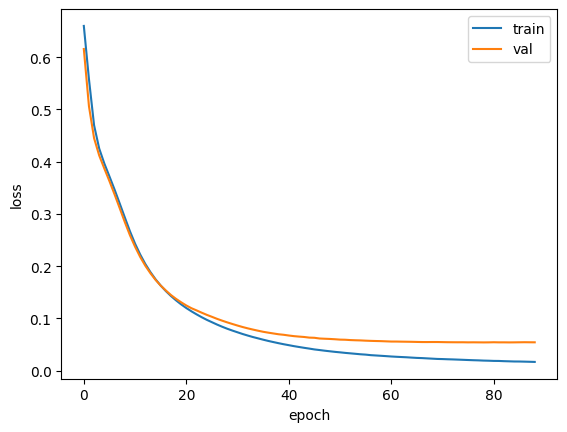

In [139]:
#시각화 해보기
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [140]:
val_loss,val_acc= model.evaluate(val_seq,val_target)
# test_loss,test_acc=model.evaluate(test_seq, test_target)

print(f"검증세트-loss:{val_loss:.4f}, accuracy:{val_acc:.4f}")
# print(f"테스트세트-loss:{test_loss:.4f}, accuracy:{test_acc:.4f}")
#모델 앞에 데이터 만드는 것이 제일 중요 500개의 데이터 

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9874 - loss: 0.0541
검증세트-loss:0.0541, accuracy:0.9874
